# CNN Baseline Notebook


In [19]:
from pathlib import Path
import csv
import os

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
os.environ.setdefault("TORCH_DISABLE_DYNAMO", "1")
os.environ.setdefault("TORCHDYNAMO_DISABLE", "1")
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_from_disk
from tqdm import tqdm


NOTEBOOK_DIR = (Path.cwd() / "CNN_baseline") if (Path.cwd() / "CNN_baseline").exists() else Path.cwd()
PLOT_DIR = NOTEBOOK_DIR / "plots"
CSV_PATH = NOTEBOOK_DIR / "cnn_mse_history.csv"


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 56 * 56, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x.squeeze(-1)


IMAGE_SIZE = (224, 224)
CHANNEL_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
CHANNEL_STD = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)


def resolve_cleaned_data_path() -> Path:
    candidates = [
        Path.cwd() / "cleaned_data",
        Path.cwd().parent / "cleaned_data",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find a cleaned_data directory for the CNN baseline notebook.")


def preprocess_image(image):
    image = image.convert("RGB").resize(IMAGE_SIZE)
    image_array = np.asarray(image, dtype=np.float32) / 255.0
    image_tensor = torch.from_numpy(image_array).permute(2, 0, 1)
    return (image_tensor - CHANNEL_MEAN) / CHANNEL_STD

def apply_transforms(examples):
    return {
        "pixel_values": [preprocess_image(img) for img in examples["image"]],
        "target_height": [torch.tensor(float(h), dtype=torch.float32) for h in examples["height"]],
    }


def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
        return device
    if torch.backends.mps.is_available():
        print("Using MPS (Apple Silicon GPU)")
        return torch.device("mps")
    print("Using CPU")
    return torch.device("cpu")


def describe_architecture():
    return [
        {"name": "Input", "shape": "3 x 224 x 224", "params": "RGB image"},
        {"name": "Conv1 + ReLU", "shape": "16 x 224 x 224", "params": "3x3, 16 filters"},
        {"name": "MaxPool1", "shape": "16 x 112 x 112", "params": "2x2"},
        {"name": "Conv2 + ReLU", "shape": "32 x 112 x 112", "params": "3x3, 32 filters"},
        {"name": "MaxPool2", "shape": "32 x 56 x 56", "params": "2x2"},
        {"name": "Flatten", "shape": "100352", "params": "32 x 56 x 56"},
        {"name": "FC1 + ReLU + Dropout", "shape": "64", "params": "100352 -> 64, p=0.5"},
        {"name": "FC2", "shape": "1", "params": "64 -> 1"},
        {"name": "Output", "shape": "Predicted height", "params": "Scalar regression"},
    ]


def print_model_summary(model):
    print("\nSimpleCNN architecture:\n")
    print(model)
    print("\nLayer flow:")
    for layer in describe_architecture():
        print(f"- {layer['name']}: output {layer['shape']} | {layer['params']}")


def plot_model_architecture(save_path: Path | None = None):
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis("off")

    sections = [
        {
            "title": "Input",
            "xy": (0.6, 4.8),
            "size": (2.2, 1.75),
            "facecolor": "#dceefb",
            "lines": ["Image tensor", "3 x 224 x 224", "Normalized RGB"],
        },
        {
            "title": "Feature Extractor",
            "xy": (3.5, 4.15),
            "size": (4.0, 2.5),
            "facecolor": "#d8f3dc",
            "lines": [
                "Conv1 + ReLU: 16 x 224 x 224",
                "MaxPool1: 16 x 112 x 112",
                "Conv2 + ReLU: 32 x 112 x 112",
                "MaxPool2: 32 x 56 x 56",
            ],
        },
        {
            "title": "Regression Head",
            "xy": (8.2, 4.15),
            "size": (4.0, 2.5),
            "facecolor": "#ffe5b4",
            "lines": [
                "Flatten: 100352",
                "FC1 + ReLU: 100352 -> 64",
                "Dropout: p = 0.5",
                "FC2: 64 -> 1",
            ],
        },
        {
            "title": "Output",
            "xy": (12.9, 4.8),
            "size": (1.8, 1.75),
            "facecolor": "#f4c2c2",
            "lines": ["Predicted", "height", "scalar"],
        },
    ]

    for section in sections:
        x, y = section["xy"]
        width, height = section["size"]
        box = FancyBboxPatch(
            (x, y),
            width,
            height,
            boxstyle="round,pad=0.06,rounding_size=0.12",
            linewidth=2,
            edgecolor="#264653",
            facecolor=section["facecolor"],
        )
        ax.add_patch(box)
        ax.text(
            x + width / 2,
            y + height - 0.42,
            section["title"],
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="#1d3557",
        )
        line_gap = 0.34
        total_text_height = line_gap * (len(section["lines"]) - 1)
        text_y = y + height - 1.0
        for line in section["lines"]:
            ax.text(
                x + width / 2,
                text_y,
                line,
                ha="center",
                va="center",
                fontsize=10,
                color="#264653",
            )
            text_y -= line_gap

    arrows = [
        ((2.8, 6.2), (3.5, 6.2)),
        ((7.5, 5.7), (8.2, 5.7)),
        ((12.2, 6.2), (12.9, 6.2)),
    ]
    for start, end in arrows:
        ax.add_patch(
            FancyArrowPatch(
                start,
                end,
                arrowstyle="simple",
                mutation_scale=18,
                linewidth=1.2,
                color="#457b9d",
                alpha=0.9,
            )
        )

    ax.text(5.5, 3.25, "Spatial encoding", ha="center", va="center", fontsize=10, style="italic", color="#457b9d")
    ax.text(10.2, 3.25, "Dense regression", ha="center", va="center", fontsize=10, style="italic", color="#9c6644")
    ax.text(
        7.7,
        1.9,
        "SimpleCNN pipeline: convolutional feature extraction followed by a small fully connected regression head.",
        ha="center",
        va="center",
        fontsize=10.5,
        color="#3d405b",
    )

    ax.set_xlim(0, 15.3)
    ax.set_ylim(1.2, 8.2)
    ax.set_title("SimpleCNN Architecture for Height Regression", fontsize=16, fontweight="bold")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def evaluate(model, loader, criterion, device, split_name):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluating {split_name} set"):
            images = batch["pixel_values"].to(device)
            targets = batch["target_height"].to(device)
            predictions = model(images)
            loss = criterion(predictions, targets)
            total_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
    mse = total_loss / total_samples
    return mse, total_samples


def train_one_epoch(model, loader, optimizer, criterion, device, epoch_idx, epochs):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for batch in tqdm(loader, desc=f"Epoch {epoch_idx}/{epochs} [Train]"):
        images = batch["pixel_values"].to(device)
        targets = batch["target_height"].to(device)
        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_samples += images.size(0)
    mse = total_loss / total_samples
    return mse, total_samples


def save_history_csv(rows):
    with CSV_PATH.open("w", newline="") as file:
        writer = csv.writer(file)
        writer.writerows(rows)
    print(f"\nSaved MSE history to {CSV_PATH}")


def plot_training_history(train_mses, val_mses):
    epoch_list = list(range(1, len(train_mses) + 1))

    plt.figure(figsize=(10, 6))
    plt.plot(epoch_list, train_mses, label="Train MSE", marker="o", linewidth=2)
    plt.plot(epoch_list, val_mses, label="Validation MSE", marker="s", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.title("CNN Baseline: MSE over Epochs")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "cnn_mse_epochs.png", dpi=200)
    plt.show()

    cumulative_train_mse = [sum(train_mses[: i + 1]) / (i + 1) for i in range(len(train_mses))]
    cumulative_val_mse = [sum(val_mses[: i + 1]) / (i + 1) for i in range(len(val_mses))]

    plt.figure(figsize=(10, 6))
    plt.plot(epoch_list, cumulative_train_mse, label="Cumulative Avg Train MSE", marker="o", linewidth=2)
    plt.plot(epoch_list, cumulative_val_mse, label="Cumulative Avg Validation MSE", marker="s", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.title("CNN Baseline: Cumulative Average MSE over Epochs")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "cnn_mse_avg_epochs.png", dpi=200)
    plt.show()


def plot_final_metrics(train_mse, val_mse, test_mse, avg_train_mse, avg_val_mse):
    plt.figure(figsize=(8, 5))
    splits = ["Train", "Validation", "Test"]
    final_mses = [train_mse, val_mse, test_mse]
    plt.bar(splits, final_mses, color=["#457b9d", "#f4a261", "#2a9d8f"])
    plt.ylabel("MSE")
    plt.title("CNN Baseline: Final Train, Validation, and Test MSE")
    for idx, value in enumerate(final_mses):
        plt.text(idx, value + 0.5, f"{value:.2f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "cnn_final_mse.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    avg_mses = [avg_train_mse, avg_val_mse, test_mse]
    plt.bar(splits, avg_mses, color=["#1d3557", "#e76f51", "#2a9d8f"])
    plt.ylabel("Average MSE")
    plt.title("CNN Baseline: Average Train/Val MSE and Final Test MSE")
    for idx, value in enumerate(avg_mses):
        plt.text(idx, value + 0.5, f"{value:.2f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "cnn_final_mse_avg.png", dpi=200)
    plt.show()



SimpleCNN architecture:

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)

Layer flow:
- Input: output 3 x 224 x 224 | RGB image
- Conv1 + ReLU: output 16 x 224 x 224 | 3x3, 16 filters
- MaxPool1: output 16 x 112 x 112 | 2x2
- Conv2 + ReLU: output 32 x 112 x 112 | 3x3, 32 filters
- MaxPool2: output 32 x 56 x 56 | 2x2
- Flatten: output 100352 | 32 x 56 x 56
- FC1 + ReLU + Dropout: output 64 | 100352 -> 64, p=0.5
- FC2: output 1 | 64 -> 1
- Output: output Predicted height | Scalar regression


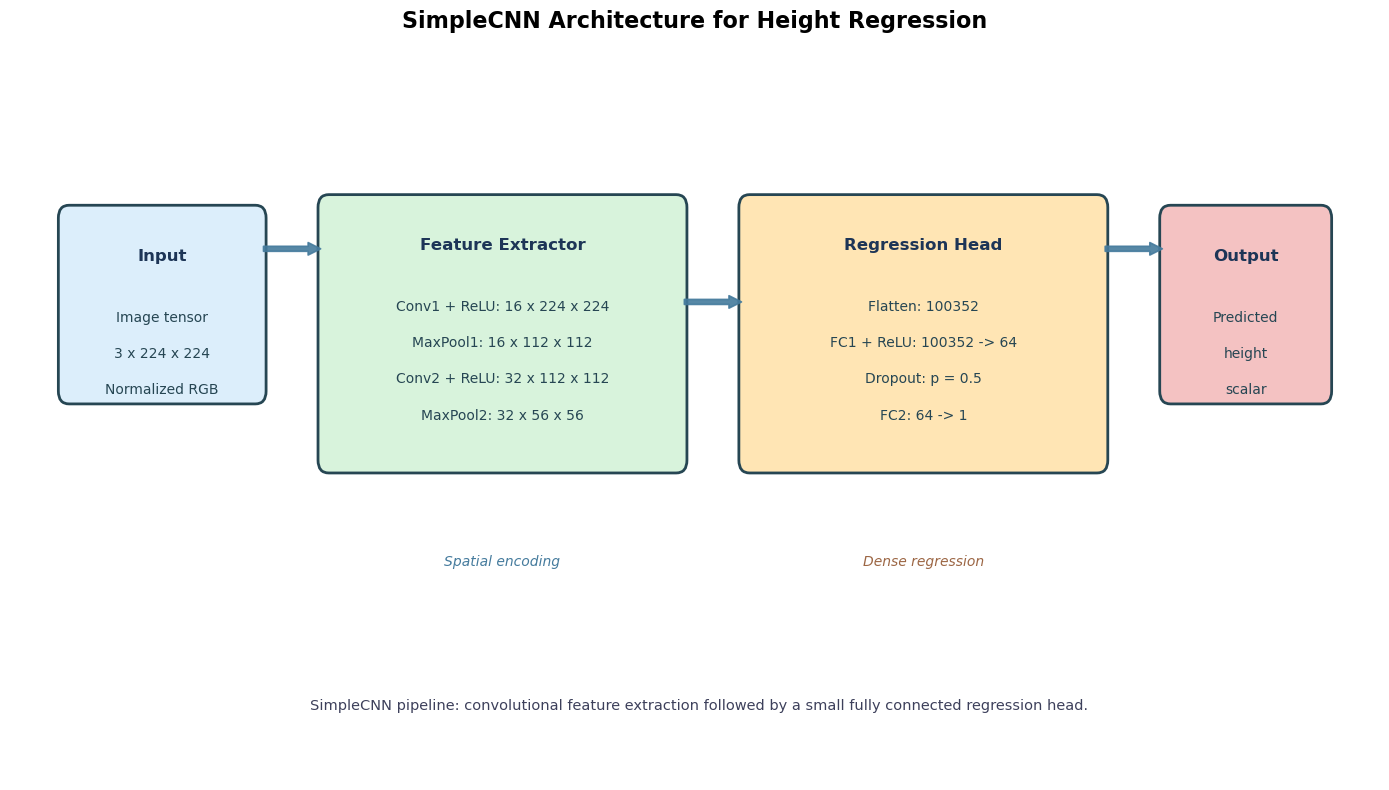

In [20]:
PLOT_DIR.mkdir(parents=True, exist_ok=True)
model = SimpleCNN()
print_model_summary(model)
plot_model_architecture(PLOT_DIR / "cnn_architecture.png")

In [ ]:
device = get_device()
dataset_path = resolve_cleaned_data_path()
print(f"Loading cleaned data from: {dataset_path}")

dataset = load_from_disk(str(dataset_path))
dataset = dataset.with_transform(apply_transforms)

train_loader = DataLoader(dataset["train"], batch_size=32, shuffle=True)
val_loader = DataLoader(dataset["validation"], batch_size=32)
test_loader = DataLoader(dataset["test"], batch_size=32)

model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
epochs = 5

train_mses = []
val_mses = []
csv_rows = [["Epoch", "Train_MSE", "Val_MSE", "Train_Samples", "Val_Samples"]]

print("\nStarting CNN Training...")
for epoch in range(1, epochs + 1):
    train_mse, train_samples = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch, epochs)
    val_mse, val_samples = evaluate(model, val_loader, criterion, device, "validation")
    train_mses.append(train_mse)
    val_mses.append(val_mse)
    csv_rows.append([epoch, train_mse, val_mse, train_samples, val_samples])
    print(f"Epoch {epoch}: Train MSE: {train_mse:.2f} | Val MSE: {val_mse:.2f}")

final_train_mse, train_samples = evaluate(model, train_loader, criterion, device, "train")
final_val_mse, val_samples = evaluate(model, val_loader, criterion, device, "validation")
test_mse, test_samples = evaluate(model, test_loader, criterion, device, "test")

print(f"\nTrain MSE: {final_train_mse:.2f}")
print(f"Number of training samples: {train_samples}")
print(f"Average MSE per training sample: {(final_train_mse / train_samples):.2f}")

print(f"Validation MSE: {final_val_mse:.2f}")
print(f"Number of validation samples: {val_samples}")
print(f"Average MSE per validation sample: {(final_val_mse / val_samples):.2f}")

print(f"Test MSE: {test_mse:.2f}")
print(f"Number of test samples: {test_samples}")
print(f"Average MSE per test sample: {(test_mse / test_samples):.2f}")

avg_train_mse = sum(train_mses) / len(train_mses)
avg_val_mse = sum(val_mses) / len(val_mses)
print(f"\nAverage MSE over {epochs} epochs:")
print(f"Train: {avg_train_mse:.2f} | Val: {avg_val_mse:.2f}")

csv_rows.append(["Average", avg_train_mse, avg_val_mse, train_samples, val_samples])
csv_rows.append(["Final", final_train_mse, final_val_mse, train_samples, val_samples])
csv_rows.append(["Test", test_mse, "", "", test_samples])
save_history_csv(csv_rows)

plot_training_history(train_mses, val_mses)
plot_final_metrics(final_train_mse, final_val_mse, test_mse, avg_train_mse, avg_val_mse)

print(f"\nPlots saved to {PLOT_DIR}")